In [1]:
# Standard library imports
import datetime
import json
import os
import platform
import subprocess
from collections import Counter
# Third-party imports
import awkward as ak
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import uproot
import vector
from tqdm import tqdm

# Register vector with awkward
vector.register_awkward()

# Set pandas options
pd.set_option('display.max_columns', None)

In [2]:
# IMPORTANT:
# I strongly recommend that you manually place 'Zss.root', 'Zbb.root', and 'Zcc.root'into  A3_SectionC_Q2/dataset directory. 
# Downloading these files using this code may be extremely slow

# Base URL for downloading files and target directory
base_url = "https://mkenzie.web.cern.ch/mkenzie/mphil/assignment/2425/FCC"
dataset_dir = "dataset"
files_to_download = ["Zbb.root", "Zss.root", "Zcc.root"]

# Create the dataset directory if it doesn't exist
if not os.path.exists(dataset_dir):
    os.makedirs(dataset_dir)

# Detect the current operating system
current_os = platform.system()
print("Detected OS:", current_os)

def download_file(fname):
    dest = os.path.join(dataset_dir, fname)
    url = f"{base_url}/{fname}"
    print(f"Downloading {fname} from {url} to {dest} ...")
    
    try:
        if current_os == "Windows":
            # On Windows, try using wget first; if it fails, try curl.
            try:
                subprocess.run(["wget", "-O", dest, url], check=True)
            except Exception as e:
                print("wget failed, trying curl")
                subprocess.run(["curl", "-L", "-o", dest, url], check=True)
        elif current_os == "Darwin":
            # On macOS, platform.system() returns "Darwin", so we use curl.
            subprocess.run(["curl", "-L", "-o", dest, url], check=True)
        elif current_os == "Linux":
            # On Linux, try using wget first; if it fails, then try curl.
            try:
                subprocess.run(["wget", "-O", dest, url], check=True)
            except Exception as e:
                print("wget failed, trying curl")
                subprocess.run(["curl", "-L", "-o", dest, url], check=True)
        else:
            print("Unsupported system. Please download manually:", url)
    except Exception as e:
        print(f"Download of {fname} failed:", e)

for fname in files_to_download:
    dest = os.path.join(dataset_dir, fname)
    if not os.path.exists(dest):
        download_file(fname)
    else:
        print(f"{fname} already exists, skipping download.")


Detected OS: Windows
Zbb.root already exists, skipping download.
Zss.root already exists, skipping download.
Zcc.root already exists, skipping download.


In [3]:
train_nums = 50000
val_nums = 15000
test_nums = 15000

flavor_map = {'Zbb': 0,'Zss': 1,'Zcc': 2}

# all variables
particle_variables = ['Thrust_x', 'Thrust_y', 'Thrust_z', 'Thrust_xerr','Thrust_yerr' ,'Thrust_zerr','Particle_e', 'nParticle','Particle_m', 'Particle_q', 'Particle_p', 'Particle_pt',
                        'Particle_eta', 'Particle_phi', 'Particle_px', 'Particle_py', 'Particle_pz','Particle_ID', 'Particle_orivtx_ind']

vertex_variables = ['Vertex_ntracks', 'Vertex_chi2', 'Vertex_isPV', 'Vertex_m',
                     'Vertex_x', 'Vertex_y', 'Vertex_z',
                     'Vertex_xerr', 'Vertex_yerr', 'Vertex_zerr']

In [4]:
# Dictionary to store DataFrames
dfs_vertex = {}
dfs_particle = {}

events_num_used = 80000

# Loop over the four files
for flavor in ['Zbb', 'Zss', 'Zcc']:
    # Load vertex data
    dfs_vertex[flavor] = ak.to_dataframe(uproot.concatenate(f"dataset/{flavor}.root", 
                                                            vertex_variables, library='ak', entry_stop = events_num_used))

    # Load particle data
    dfs_particle[flavor] = ak.to_dataframe(uproot.concatenate(f"dataset/{flavor}.root",
                                                               particle_variables, library='ak', entry_stop = events_num_used))

# Create a new column in all vertex dfs, a total error information
for flavor in ['Zbb', 'Zss', 'Zcc']:
    df = dfs_vertex[flavor]
    df["Vertex_err"] = np.sqrt(df["Vertex_xerr"]**2 + df["Vertex_yerr"]**2 + df["Vertex_zerr"]**2)

# Create a new column in all thrust dfs, a total error information
for flavor in ['Zbb', 'Zss', 'Zcc']:
    df = dfs_particle[flavor]
    df["Thrust_err"] = np.sqrt(df["Thrust_xerr"]**2 + df["Thrust_yerr"]**2 + df["Thrust_zerr"]**2)

# delete information
for flavor in ['Zbb', 'Zss', 'Zcc']:
    dfs_vertex[flavor].drop(columns=["Vertex_xerr", "Vertex_yerr", "Vertex_zerr"], inplace=True)
    dfs_particle[flavor].drop(columns=["Thrust_xerr", "Thrust_yerr", "Thrust_zerr"], inplace=True)

# flavor_events = {'Zbb':198068, 'Zcc':199784,'Zss':212355}

flavor_events = {'Zbb':events_num_used,
                'Zcc':events_num_used,
                'Zss':events_num_used}

In [5]:
dfs_vertex['Zbb']

Vertex_ntracks  Vertex_chi2  Vertex_isPV   Vertex_m  \
entry subentry                                                        
0     0                      9     1.325023            1   9.378078   
      1                      2     2.062392            0   0.010154   
      2                      3     0.370612            0   0.726321   
      3                      2     1.593721            0   0.639538   
1     0                     11     1.577453            1  21.259911   
...                        ...          ...          ...        ...   
79998 4                      2     2.605372            0   0.492963   
79999 0                      7     0.706265            1   7.887752   
      1                      3     0.711874            0   1.968780   
      2                      2     7.847215            0   0.529450   
      3                      2  9898.458984            0   0.427196   

                  Vertex_x      Vertex_y    Vertex_z  Vertex_err  
entry subentry                                                    
0     0           0.001161 -1.464803e-07   -0.018201    0.002990  
      1          -4.088748  2.836729e+00   -0.834998   10.976404  
      2           0.842234  1.427307e-01    1.186171    0.029207  
      3           1.788945  2.505793e-01    2.562661    0.074629  
1     0           0.006506  1.958121e-07    0.494196    0.003071  
...                    ...           ...         ...         ...  
79998 4           0.994262 -2.547343e+00    1.655858    0.033361  
79999 0           0.006286  8.270590e-08   -0.294391    0.004217  
      1          -0.271175 -5.934811e-01   -0.849488    0.018955  
      2           1.156504  3.111269e+00    2.685529    0.078120  
      3        -124.163498 -4.214167e+02 -402.354828    2.013675  

[381729 rows x 8 columns]

In [6]:
# show the final particle at end of each flavor

particle_id_to_name = {22: "photon",-211: "pi-",211: "pi+",321: "K+",-321: "K-",
    130: "K_L0",2212: "proton",-2212: "antiproton",2112: "neutron",-2112: "antineutron",
    11: "electron",-11: "positron",13: "mu-",-13: "mu+",0: "unknown"}

particle_name_mapper = {}

for flavor in ['Zbb', 'Zss', 'Zcc']:
    particle_ids = dfs_particle[flavor]['Particle_ID'].tolist()
    unique_ids = sorted(set(particle_ids))
    particle_names = [particle_id_to_name[pid] for pid in unique_ids]
    particle_name_mapper[flavor] = particle_names
    print(particle_name_mapper[flavor])

['antiproton', 'antineutron', 'K-', 'pi-', 'mu+', 'positron', 'unknown', 'electron', 'mu-', 'photon', 'K_L0', 'pi+', 'K+', 'neutron', 'proton']
['antiproton', 'antineutron', 'K-', 'pi-', 'mu+', 'positron', 'unknown', 'electron', 'mu-', 'photon', 'K_L0', 'pi+', 'K+', 'neutron', 'proton']
['antiproton', 'antineutron', 'K-', 'pi-', 'mu+', 'positron', 'unknown', 'electron', 'mu-', 'photon', 'K_L0', 'pi+', 'K+', 'neutron', 'proton']


In [7]:
# Entry level shuffle

for flavor in tqdm(['Zbb', 'Zss', 'Zcc']):
    df_particle = dfs_particle[flavor]
    unique_entries = df_particle.index.get_level_values(0).unique()
    shuffled_entries = np.random.permutation(unique_entries)
    dfs_particle[flavor] = pd.concat(
        [df_particle.loc[entry] for entry in shuffled_entries],
        keys=shuffled_entries,
        names=df_particle.index.names)

    df_vertex = dfs_vertex[flavor]
    dfs_vertex[flavor] = pd.concat(
        [df_vertex.loc[entry] for entry in shuffled_entries],
        keys=shuffled_entries,
        names=df_vertex.index.names)

100%|██████████| 3/3 [01:32<00:00, 30.86s/it]


In [8]:
# fill NaN with median

for flavor in ['Zbb', 'Zss', 'Zcc']:
    df = dfs_particle[flavor]
    # Compute the median of Thrust_err ignoring NaN values
    median_val = np.nanmedian(df['Thrust_err'].values)
    # Fill NaN values with the computed median
    df['Thrust_err'] = np.where(np.isnan(df['Thrust_err'].values), median_val, df['Thrust_err'].values)
    print(f"Flavor {flavor}: filled NaNs in 'Thrust_err' with median value {median_val}")
    dfs_particle[flavor] = df  # update the dataframe in the dictionary

Flavor Zbb: filled NaNs in 'Thrust_err' with median value 28.914598290370247
Flavor Zss: filled NaNs in 'Thrust_err' with median value 28.18283709955038
Flavor Zcc: filled NaNs in 'Thrust_err' with median value 28.415937533332173


In [9]:
# Compute angle between thrust and momentum, then delete Thrust_x/y/z

for flavor in ['Zss', 'Zbb', 'Zcc']:
    
    p3 = ak.zip({ # 3D momentum vector
        "x": dfs_particle[flavor]["Particle_px"],
        "y": dfs_particle[flavor]["Particle_py"],
        "z": dfs_particle[flavor]["Particle_pz"]}, with_name="Vector3D")

    thrust = ak.zip({ # 3D thrust vector
        "x": dfs_particle[flavor]["Thrust_x"],
        "y": dfs_particle[flavor]["Thrust_y"],
        "z": dfs_particle[flavor]["Thrust_z"]}, with_name="Vector3D")
    
    # Compute angle between momentum and thrust vector
    dfs_particle[flavor]["Particle_angle_to_thrust"] = thrust.deltaangle(p3)
    dfs_particle[flavor].drop(columns=["Thrust_x", "Thrust_y", "Thrust_z"], inplace=True)

<!-- # 提取数据

for flavor in ['Zbb', 'Zss', "Zcc"]:
    data = np.log(dfs_particle[flavor]['Particle_m'])

    # 计算 99.98% 分位数作为上限
    # x_max = data.quantile(0.99)

    # 绘制直方图
    plt.hist(data, bins=60)

    # 设置 x 轴范围（下限保持默认，上限设为分位数值）


    # 显示图形
    plt.show() -->

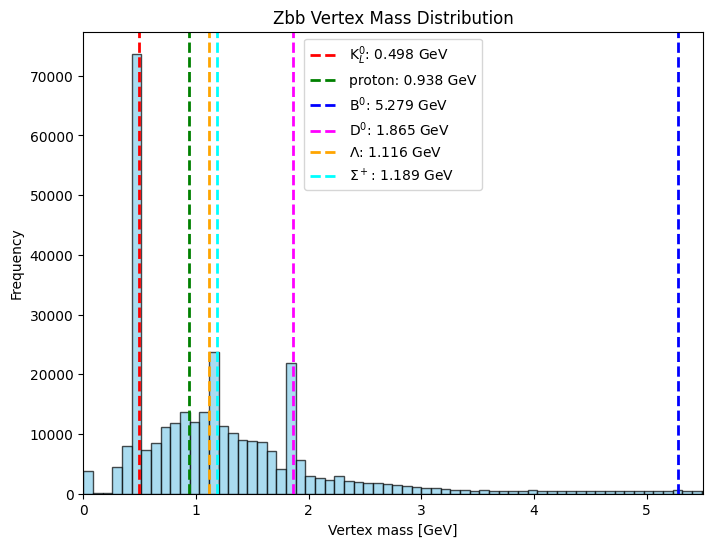

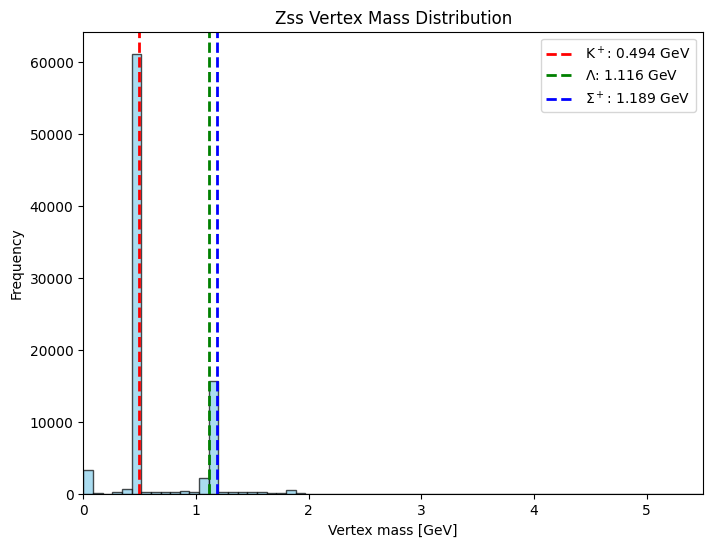

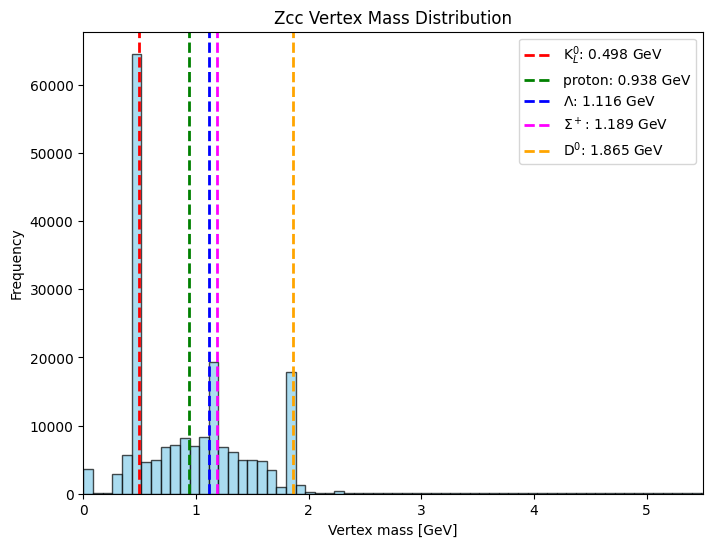

In [10]:
# Plot vertex mass distributions with selected candidate particle overlays (non-log scale)
# Only use vertex mass data in the range 0–6 GeV

for flavor in ['Zbb', 'Zss', 'Zcc']:
    # Use original vertex mass data (non-log scale)
    data = dfs_vertex[flavor]['Vertex_m']
    
    # Select data in the range 0 to 6 GeV
    data = data[(data >= 0) & (data <= 6)]
    
    # Define candidate particles for each flavor:
    if flavor == 'Zbb':
        # Candidates for Z→b b̄: [K_L0, proton, B, D0, Lambda, Sigma+, D+]
        expected_particles = [
            ('K$_L^0$', 0.498),
            ('proton', 0.938),
            ('B$^0$', 5.279),
            ('D$^0$', 1.865),
            ('$\Lambda$', 1.116),
            ('$\Sigma^+$', 1.189)]
        candidate_colors = ['red', 'green', 'blue', 'magenta', 'orange', 'cyan']
    elif flavor == 'Zss':
        # Candidates for Z→s s̄: [K+, Lambda, Sigma+]
        expected_particles = [('K$^+$', 0.494),('$\Lambda$', 1.116),('$\Sigma^+$', 1.189)]
        candidate_colors = ['red', 'green', 'blue']
    elif flavor == 'Zcc':
        # Candidates for Z→c c̄: [K_L0, proton, Lambda, Sigma+, D0]
        expected_particles = [('K$_L^0$', 0.498),('proton', 0.938),  ('$\Lambda$', 1.116), ('$\Sigma^+$', 1.189),('D$^0$', 1.865)]
        candidate_colors = ['red', 'green', 'blue', 'magenta', 'orange']
    
    # Create the histogram plot
    plt.figure(figsize=(8, 6))
    plt.hist(data, bins=70, alpha=0.7, color='skyblue', edgecolor='black', label='Vertex mass distribution')
    
    # Overlay vertical dashed lines for each candidate particle using distinct colors
    line_handles = []
    line_labels = []
    for (particle, mass), col in zip(expected_particles, candidate_colors):
        line = plt.axvline(x=mass, color=col, linestyle='--', linewidth=2)
        line_handles.append(line)
        line_labels.append(f'{particle}: {mass} GeV')
    
    # Set axis labels, title, legend, and x-axis limits
    plt.xlabel('Vertex mass [GeV]')
    plt.ylabel('Frequency')
    plt.title(f'{flavor} Vertex Mass Distribution')
    plt.xlim(0, 5.5)
    plt.legend(line_handles, line_labels)
    plt.show()

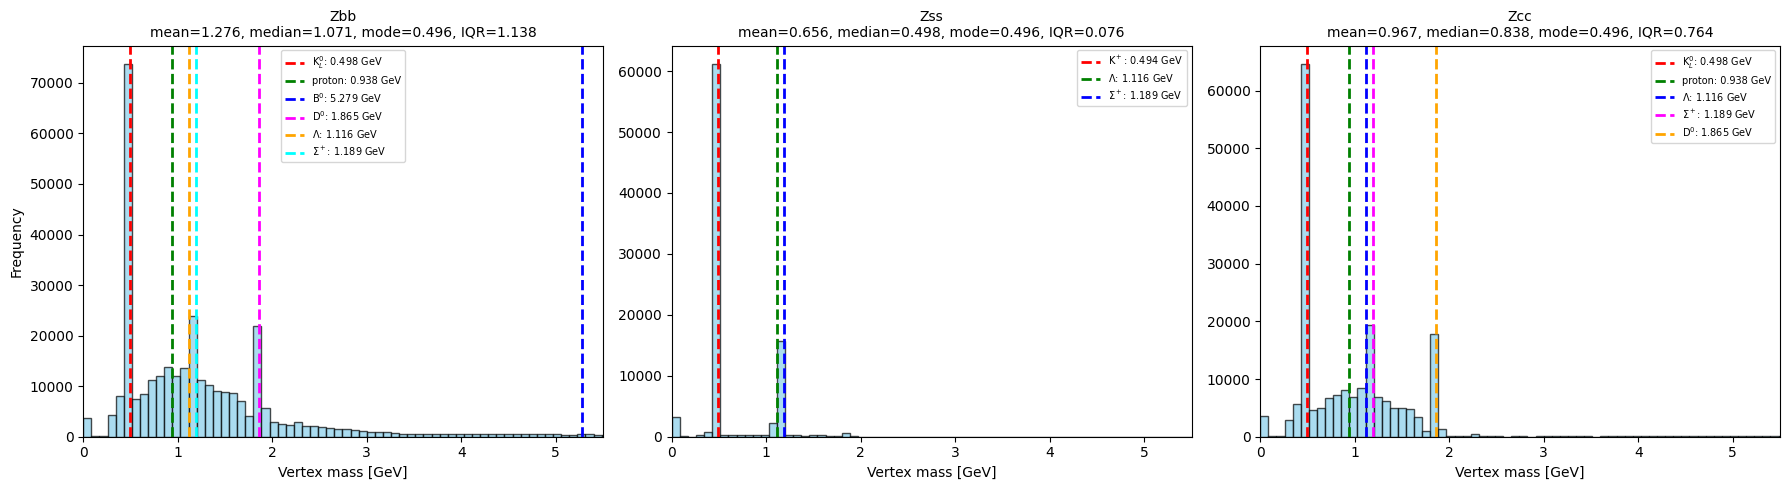

In [11]:
def hist_mode(arr, nbins=200):
    """Return the centre of the histogram bin with the highest count."""
    hist, edges = np.histogram(arr, bins=nbins)
    idx = np.argmax(hist)
    return 0.5 * (edges[idx] + edges[idx + 1])

# ── 1×3 画板，不共享 y 轴 ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, flavor in zip(axes, ['Zbb', 'Zss', 'Zcc']):
    # vertex-mass 0–6 GeV
    data = dfs_vertex[flavor]['Vertex_m']
    data = data[(data >= 0) & (data <= 6)]

    # ── stats ──
    mean   = np.mean(data)
    median = np.median(data)
    mode   = hist_mode(data)
    iqr    = np.percentile(data, 75) - np.percentile(data, 25)   # 四分位距

    # ── expected lines & colours ──
    if flavor == 'Zbb':
        expected_particles = [('K$_L^0$',0.498),('proton',0.938),
                              ('B$^0$',5.279),('D$^0$',1.865),
                              ('$\Lambda$',1.116),('$\Sigma^+$',1.189)]
        candidate_colors   = ['red','green','blue','magenta','orange','cyan']
    elif flavor == 'Zss':
        expected_particles = [('K$^+$',0.494),('$\Lambda$',1.116),('$\Sigma^+$',1.189)]
        candidate_colors   = ['red','green','blue']
    else:  # Zcc
        expected_particles = [('K$_L^0$',0.498),('proton',0.938),
                              ('$\\Lambda$',1.116),('$\\Sigma^+$',1.189),('D$^0$',1.865)]
        candidate_colors   = ['red','green','blue','magenta','orange']

    # ── plot ──
    ax.hist(data, bins=70, alpha=0.7, color='skyblue', edgecolor='black')
    for (particle, mass), col in zip(expected_particles, candidate_colors):
        ax.axvline(x=mass, color=col, linestyle='--', linewidth=2,
                   label=f'{particle}: {mass} GeV')

    ax.set_xlim(0, 5.5)
    ax.set_xlabel('Vertex mass [GeV]')
    ax.set_title(f'{flavor}\nmean={mean:.3f}, median={median:.3f}, '
                 f'mode={mode:.3f}, IQR={iqr:.3f}', fontsize=10)
    ax.legend(fontsize=7)

axes[0].set_ylabel('Frequency')
plt.tight_layout()
plt.show()


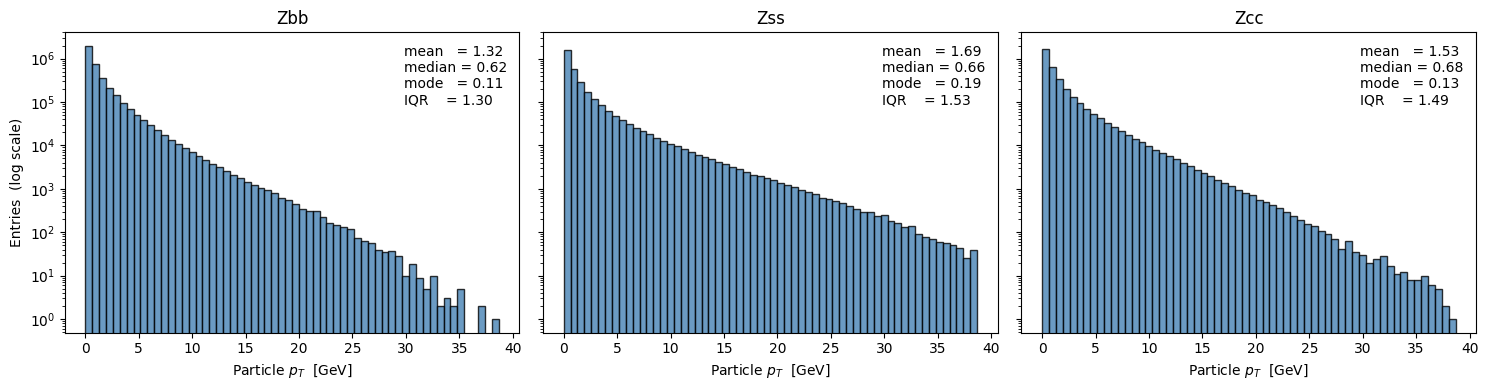

In [12]:
# == 画 Particle_pt 线性-x / 对数-y 分布（剔除 top-0.01 %） ==

flavours = ['Zbb', 'Zss', 'Zcc']
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# 先把所有 pt 拼一起，计算全局 99.99-th percentile
all_pt = np.concatenate([dfs_particle[f]['Particle_pt'].to_numpy() for f in flavours])
pt_cut = np.percentile(all_pt, 99.999)           # 分位阈值
n_bins = 60
lin_edges = np.linspace(all_pt.min(), pt_cut, n_bins + 1)   # 用截断后范围等宽分 bin

for ax, flav in zip(axes, flavours):
    pt_raw = dfs_particle[flav]['Particle_pt'].to_numpy()
    # 1) 去掉≤0  2) 去掉极高异常值 (>99.99%)
    pt_raw = pt_raw[(pt_raw > 0) & (pt_raw <= pt_cut)]

    mean   = pt_raw.mean()
    median = np.median(pt_raw)
    mode_v = pd.Series(pt_raw).mode().iloc[0]
    iqr    = np.percentile(pt_raw, 75) - np.percentile(pt_raw, 25)

    counts, _ = np.histogram(pt_raw, bins=lin_edges)
    bin_centers = 0.5 * (lin_edges[:-1] + lin_edges[1:])

    ax.bar(bin_centers, counts,
           width=np.diff(lin_edges),
           color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_yscale('log')                     # 纵轴对数
    ax.set_xlabel(r'Particle $p_{T}$  [GeV]')
    ax.set_title(flav)

    stats_txt = (f"mean   = {mean:.2f}\n"
                 f"median = {median:.2f}\n"
                 f"mode   = {mode_v:.2f}\n"
                 f"IQR    = {iqr:.2f}")
    ax.plot([], [], ' ', label=stats_txt)
    ax.legend(loc='upper right', frameon=False, fontsize=10)

axes[0].set_ylabel('Entries  (log scale)')
plt.tight_layout()
plt.show()


<!-- # 3×3 网格：行 = flavour，列 = Vertex_x / y / z
coords    = ['Vertex_x', 'Vertex_y', 'Vertex_z']
flavours  = ['Zbb', 'Zss', 'Zcc']
fig, axes = plt.subplots(3, 3, figsize=(15, 9), sharey=False)

for i, flav in enumerate(flavours):
    for j, coord in enumerate(coords):
        ax   = axes[i, j]
        data = dfs_vertex[flav][coord].values

        # 去掉最小 0.02 % 与最大 99.98 % 极端点
        low, high = np.percentile(data, [0.02, 99.98])
        data_clipped = data[(data >= low) & (data <= high)]

        ax.hist(data_clipped, bins=60, color='skyblue', edgecolor='black')
        ax.set_yscale('log')                         # y 轴用对数尺度

        if i == 0:
            ax.set_title(coord)                     # 顶行列标题
        if j == 0:
            ax.set_ylabel(f'{flav}\nEntries')       # 左列行标签
        ax.set_xlabel(coord)

plt.tight_layout()
plt.show() -->


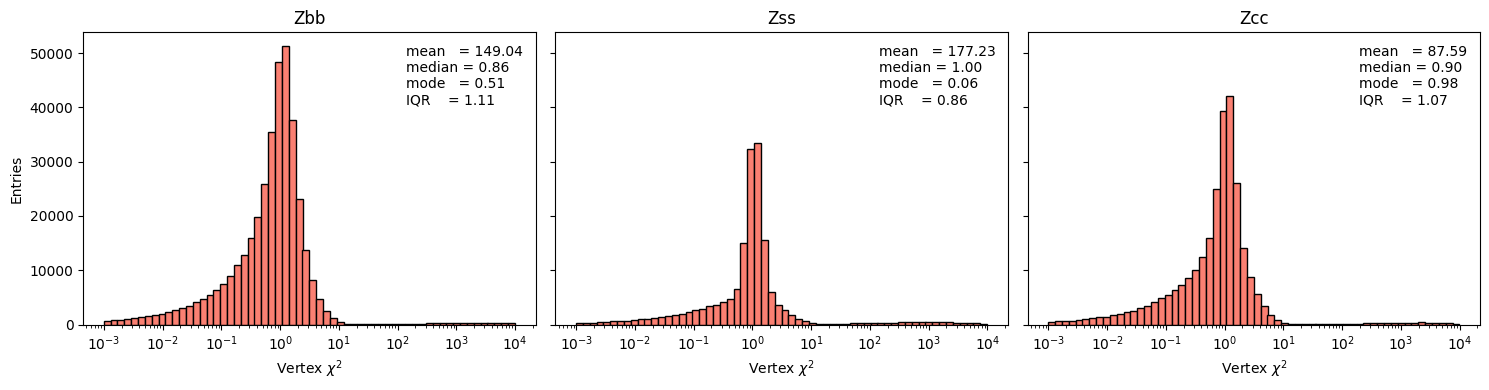

In [13]:
# 指定统一的 log-x 区间：10⁻¹ → 10⁵
x_lo, x_hi = 1e-3, 1e4
n_bins     = 60                                 # 60 个等比 bin

flavours = ['Zbb', 'Zss', 'Zcc']
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# 预先生成全局等比 bin（所有 flavour 共用）
log_edges = np.logspace(np.log10(x_lo), np.log10(x_hi), n_bins + 1)

for ax, flav in zip(axes, flavours):
    # ---------- 1) 拿原始 χ²，过滤负值 ----------
    chi2_raw = dfs_vertex[flav]['Vertex_chi2'].to_numpy()
    chi2_raw = chi2_raw[chi2_raw > 0]
    iqr    = np.percentile(chi2_raw, 75) - np.percentile(chi2_raw, 25)
    mean   = chi2_raw.mean()
    median = np.median(chi2_raw)
    
    mode_val = pd.Series(chi2_raw).mode().iloc[0]  # 若多解取最小
    # ---------- 2) 截断到 [10⁻¹, 10⁵] ----------
    chi2 = chi2_raw[(chi2_raw >= x_lo) & (chi2_raw <= x_hi)]

    # ---------- 3) 直方图（线性 y，log-x） ----------
    counts, _ = np.histogram(chi2, bins=log_edges)
    ax.bar((log_edges[:-1] * log_edges[1:])**0.5,     # bin 几何中心
           counts,
           width=np.diff(log_edges),
           color='salmon',
           edgecolor='black')
    ax.set_xscale('log')
    ax.set_xlabel(r'Vertex $\chi^{2}$')
    ax.set_title(flav)

    # ---------- 4) 统计量 ----------

    stats_txt = (f"mean   = {mean:.2f}\n"
                 f"median = {median:.2f}\n"
                 f"mode   = {mode_val:.2f}\n"
                 f"IQR    = {iqr:.2f}")
    ax.plot([], [], ' ', label=stats_txt)
    ax.legend(loc='upper right', frameon=False, fontsize=10)

axes[0].set_ylabel('Entries')          # 线性 y 轴
plt.tight_layout()
plt.show()


<!-- import numpy as np
import matplotlib.pyplot as plt

flavours = ['Zbb', 'Zss', 'Zcc']
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, flav in zip(axes, flavours):
    ntrk = dfs_vertex[flav]['Vertex_ntracks'].to_numpy(dtype=int)

    # -------- 1. 画直方图（整数等宽 bin） --------
    bins = np.arange(ntrk.min(), ntrk.max() + 2)        # 每 1 个 ntracks 一格
    ax.hist(ntrk, bins=bins, color='skyblue', edgecolor='black')
    ax.set_yscale('log')
    ax.set_xlabel('Vertex ntracks')
    ax.set_title(flav)

    # -------- 2. 统计量（无 Python 循环） --------
    mean   = ntrk.mean()
    median = np.median(ntrk)
    # 直接用 bincount 找出现次数最多的整数
    mode_val = np.argmax(np.bincount(ntrk))
    iqr      = np.percentile(ntrk, 75) - np.percentile(ntrk, 25)

    stats_txt = (f"mean   = {mean:.1f}\n"
                 f"median = {int(median)}\n"
                 f"mode   = {mode_val}\n"
                 f"IQR    = {int(iqr)}")
    ax.plot([], [], ' ', label=stats_txt)
    ax.legend(loc='upper right', frameon=False, fontsize=10)

axes[0].set_ylabel('Entries')
plt.tight_layout()
plt.show() -->


<!-- def cont_mode(arr, nbins=200):
    """连续变量众数：取最高柱中心值"""
    hist, edges = np.histogram(arr, bins=nbins)
    idx = np.argmax(hist)
    return 0.5 * (edges[idx] + edges[idx + 1])

flavours = ['Zbb', 'Zss', 'Zcc']           # 列 → flavour
fig, axes = plt.subplots(
        2, 3, figsize=(15, 8), dpi=300,    # 这里提高 DPI
        sharey=False)                      # 行0=Lxy, 行1=z

for j, flav in enumerate(flavours):
    vx = dfs_vertex[flav]['Vertex_x'].values
    vy = dfs_vertex[flav]['Vertex_y'].values
    vz = dfs_vertex[flav]['Vertex_z'].values

    Lxy = np.sqrt(vx**2 + vy**2)
    z    = vz

    for i, data in enumerate([Lxy, z]):    # i=0→Lxy 行, i=1→z 行
        ax = axes[i, j]

        low, high = np.percentile(data, [0.01, 99.99])
        data_clip = data[(data >= low) & (data <= high)]

        ax.hist(data_clip, bins=60, color='skyblue', edgecolor='black')
        ax.set_yscale('log')

        # 统计量
        mn   = np.min(data_clip)
        mx   = np.max(data_clip)
        mean = np.mean(data_clip)
        med  = np.median(data_clip)
        mode_v = cont_mode(data_clip)
        iqr  = np.percentile(data_clip, 75) - np.percentile(data_clip, 25)

        stats = (f"range: [{mn:.2f}, {mx:.2f}]\n"
                 f"IQR (Q₇₅–Q₂₅) = {iqr:.2f}\n"
                 f"mean = {mean:.2f}\n"
                 f"median = {med:.2f}\n"
                 f"mode = {mode_v:.2f}")
        ax.plot([], [], ' ', label=stats)
        ax.legend(loc='upper right', frameon=False, fontsize=9)

        # 轴标签
        if i == 1:
            ax.set_xlabel('Entries')
        if i == 0:
            ax.set_xlabel(r'$R_{xy}\;[\mathrm{mm}]$')
        else:
            ax.set_xlabel(r'$z\;[\mathrm{mm}]$')

        if j == 0:                         # 仅左列加 y 轴标签
            if i == 0:
                ax.set_ylabel('Entries\n(Lxy)')
            else:
                ax.set_ylabel('Entries\n(z)')

# 顶端标题：每列写 flavour
for j, flav in enumerate(flavours):
    axes[0, j].set_title(flav)

plt.tight_layout()
plt.show() -->


In [14]:
for flavor in ['Zbb', 'Zss', 'Zcc']:
    # 1) Particle part
    df_particle = dfs_particle[flavor]

    # Drop px, py, pz
    df_particle.drop(columns=['Particle_px', 'Particle_py', 'Particle_pz'], inplace=True)
    
    # Log transform for Particle_e, Particle_p, Particle_pt, Thrust_err
    for col in ['Particle_e', 'Particle_p', 'Particle_pt', 'Thrust_err']:
        new_col = col + "_log"
        # Use clip to avoid log(0) or log(negative)
        df_particle[new_col] = np.log(df_particle[col].clip(1e-6, None))
        df_particle.drop(columns=[col], inplace=True)
    
    # Update dictionary
    dfs_particle[flavor] = df_particle

    # 2) Vertex part
    df_vertex = dfs_vertex[flavor]
    
    # Log transform for Vertex_chi2, Vertex_m, Vertex_err
    for col in ['Vertex_chi2', 'Vertex_m', 'Vertex_err']:
        new_col = col + "_log"
        df_vertex[new_col] = np.log(df_vertex[col].clip(1e-6, None))
        df_vertex.drop(columns=[col], inplace=True)
    
    # Update dictionary
    dfs_vertex[flavor] = df_vertex

print("Removed Particle_px/py/pz and log-transformed specified columns for both particle and vertex DataFrames.")


Removed Particle_px/py/pz and log-transformed specified columns for both particle and vertex DataFrames.


In [15]:
# Convert 2 angles to sin and cos

for flavor in ['Zbb', 'Zss', 'Zcc']:
    df = dfs_particle[flavor]
    # Compute sin and cos for Particle_phi
    df['Particle_phi_sin'] = np.sin(df['Particle_phi'].values)
    df['Particle_phi_cos'] = np.cos(df['Particle_phi'].values)
    # Compute sin and cos for Particle_angle_to_thrust
    df['Particle_angle_to_thrust_sin'] = np.sin(df['Particle_angle_to_thrust'].values)
    df['Particle_angle_to_thrust_cos'] = np.cos(df['Particle_angle_to_thrust'].values)
    # Remove the original angle columns
    df.drop(columns=['Particle_phi', 'Particle_angle_to_thrust'], inplace=True)
    # Update the dictionary entry
    dfs_particle[flavor] = df

print("Particle_phi and Particle_angle_to_thrust have been converted to sin and cos, and original columns removed.")

Particle_phi and Particle_angle_to_thrust have been converted to sin and cos, and original columns removed.


<!-- # find in both particle dfs and vertex dfs, which columns contains -999

par_col_w_m999 = []
ver_col_w_m999 = []

for flavor in ['Zbb', 'Zss', 'Zcc']:
    df_par = dfs_particle[flavor]
    for col in df_par.columns:
        if (df_par[col] == -999).any():
            if col not in par_col_w_m999:
                par_col_w_m999.append(col)
                
    df_ver = dfs_vertex[flavor]
    for col in df_ver.columns:
        if (df_ver[col] == -999).any():
            if col not in ver_col_w_m999:
                ver_col_w_m999.append(col)

print("Columns in original particle data with -999:", par_col_w_m999)
print("Columns in original vertex data with -999", ver_col_w_m999) -->

In [16]:
# Define the number of events to process per flavor

traceable_counts = []
charged_counts = []
vertex_count = []

for flavor in tqdm(['Zbb', 'Zss', 'Zcc']):
    # Particle part: only take the first 'train_nums' rows using loc
    df_particle_sub = dfs_particle[flavor].loc[:train_nums]
    grouped_particle = df_particle_sub.groupby(level="entry")
    
    # Count the number of traceable particles (Particle_orivtx_ind != -999)
    traceable_series = grouped_particle["Particle_orivtx_ind"].apply(lambda s: np.sum(s != -999))
    traceable_counts.extend(traceable_series.values)
    
    # Count the number of charged particles (Particle_q != 0)
    charged_series = grouped_particle["Particle_q"].apply(lambda s: np.sum(s != 0))
    charged_counts.extend(charged_series.values)
    
    # Vertex part: only take the first 'train_nums' rows using loc
    df_vertex_sub = dfs_vertex[flavor].loc[:train_nums]
    grouped_vertex = df_vertex_sub.groupby(level="entry")
    
    # Count the number of vertices per event
    vertex_series = grouped_vertex.size()
    vertex_count.extend(vertex_series.values)

# Print out the results
print("Mean of traceable count per evennts:", np.mean(traceable_counts))
print("Mean of charged counts per event:", np.mean(charged_counts))
print("Mean of vertex counts:", np.mean(vertex_count))

100%|██████████| 3/3 [00:19<00:00,  6.56s/it]

Mean of traceable count per evennts: 19.01130480020479
Mean of charged counts per event: 20.077506833252134
Mean of vertex counts: 3.5462142544529685


In [17]:
def build_temp_dicts(train_nums, dfs_particle, dfs_vertex, particle_columns_proc, vertex_columns_proc):
    """
    Build temporary dictionaries for particle and vertex variables.
    
    Parameters:
        train_nums (int): The number of events to process per flavor.
        dfs_particle (dict): Dictionary of particle DataFrames, keyed by flavor.
        dfs_vertex (dict): Dictionary of vertex DataFrames, keyed by flavor.
        particle_columns_proc (list): List of particle variable names to process.
        vertex_columns_proc (list): List of vertex variable names to process.
    
    Returns:
        (particle_temp_dict, vertex_temp_dict): Two dictionaries containing the processed data.
    """
    particle_temp_dict = {col: [] for col in particle_columns_proc}
    vertex_temp_dict = {col: [] for col in vertex_columns_proc}
    
    from tqdm import tqdm
    for flavor in tqdm(['Zbb', 'Zss', 'Zcc']):
        for particle_col in particle_columns_proc:
            for i in range(train_nums):
                if particle_col == 'nParticle' or particle_col == 'Thrust_err_log':  # only take one value from each entry
                    value = dfs_particle[flavor].loc[i][particle_col][0]
                    particle_temp_dict[particle_col].append(value)
                else:
                    par_temp_list = dfs_particle[flavor].loc[i][particle_col].values
                    particle_temp_dict[particle_col].extend(par_temp_list.tolist())
        
        for vertex_col in vertex_columns_proc:
            for i in range(train_nums):
                data = dfs_vertex[flavor].loc[i][vertex_col]
                if np.isscalar(data):
                    vertex_temp_dict[vertex_col].append(data)
                else:
                    vertex_temp_dict[vertex_col].extend(data.values.tolist())
    
    # # Remove NaN values from Thrust_err
    # thrust_err_arr = np.array(particle_temp_dict["Thrust_err_log"])
    # thrust_err_arr = thrust_err_arr[~np.isnan(thrust_err_arr)]
    # particle_temp_dict["Thrust_err_log"] = thrust_err_arr.tolist()
    
    return particle_temp_dict, vertex_temp_dict

particle_columns_proc = ['Particle_e_log', 'Particle_m', 'Particle_p_log', 'Particle_pt_log', "Thrust_err_log",
                         'Particle_eta', 'nParticle']

vertex_columns_proc = ['Vertex_ntracks','Vertex_chi2_log','Vertex_m_log','Vertex_x','Vertex_y','Vertex_z',"Vertex_err_log"]

In [18]:
def plot_and_save_hist(feature_name, values, data_type, save_dir, plot = False):
    """
    This function plots and saves a histogram for a given feature, and returns the computed statistics.
    
    Parameters:
        feature_name (str): The name of the feature.
        values (list or array): The data values of the feature.
        data_type (str): The type of data (e.g., "Particle" or "Vertex").
        save_dir (str): The directory where the histogram image will be saved.
    
    Returns:
        (mean_val, std_val, median_val, p0_02, p99_98, min_val, max_val)
    """
    # Convert values to numpy array
    arr = np.array(values)
    
    # Compute statistics
    mean_val   = np.mean(arr)
    std_val    = np.std(arr)
    median_val = np.median(arr)
    p0_02      = np.percentile(arr, 0.02)
    p99_98     = np.percentile(arr, 99.98)
    min_val    = np.min(arr)
    max_val    = np.max(arr)
    
    # Create histogram plot
    plt.figure(figsize=(6, 4))
    plt.hist(arr, bins=50, alpha=0.7, edgecolor='black')
    plt.xlabel(feature_name)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {feature_name} ({data_type})")
    plt.tight_layout()
    
    # Prepare legend text with statistical information
    legend_text = (f"Mean: {mean_val:.2f}\n"
                   f"Std: {std_val:.2f}\n"
                   f"Median: {median_val:.2f}\n"
                   f"0.02%: {p0_02:.2f}\n"
                   f"99.98%: {p99_98:.2f}\n"
                   f"Min: {min_val:.2f}\n"
                   f"Max: {max_val:.2f}")
    
    plt.plot([], [], ' ', label=legend_text)
    plt.legend(loc='upper right')
    
    # Save the histogram image
    file_name = f"{data_type.lower()}_{feature_name}_hist.png"
    save_path = os.path.join(save_dir, file_name)
    plt.savefig(save_path)
    if plot:
        plt.show()
    plt.close()
    return mean_val, std_val, median_val, p0_02, p99_98, min_val, max_val

In [19]:
# # This cell takes 5minutes to run
# # Now, use the plot_and_save_hist function to plot and save histograms for these count variables.
# # The save_dir is defined as follows:
# save_dir = os.path.join("results", "raw_hist")
# if not os.path.exists(save_dir):
#     os.makedirs(save_dir)

# particle_temp_dict, vertex_temp_dict = build_temp_dicts(train_nums, dfs_particle, dfs_vertex, particle_columns_proc, vertex_columns_proc)

# # Process event-level count variables
# stats_traceable = plot_and_save_hist("traceable_counts", traceable_counts, "Event", save_dir,True)
# stats_charged = plot_and_save_hist("charged_counts", charged_counts, "Event", save_dir,True)
# stats_vertex  = plot_and_save_hist("vertex_count", vertex_count, "Event", save_dir,True)

# # Process particle-level features
# particle_stats = {}
# for feature, values in particle_temp_dict.items():
#     stats = plot_and_save_hist(feature, values, "Particle", save_dir,True)
#     particle_stats[feature] = {
#         "mean": stats[0],
#         "std": stats[1],
#         "median": stats[2],
#         "p0_02": stats[3],
#         "p99_98": stats[4],
#         "min": stats[5],
#         "max": stats[6]}

# # Process vertex-level features
# vertex_stats = {}
# for feature, values in vertex_temp_dict.items():
#     stats = plot_and_save_hist(feature, values, "Vertex", save_dir,True)
#     vertex_stats[feature] = {
#         "mean": stats[0],
#         "std": stats[1],
#         "median": stats[2],
#         "p0_02": stats[3],
#         "p99_98": stats[4],
#         "min": stats[5],
#         "max": stats[6]}

# # Combine all statistics into one dictionary
# all_stats_raw_raw = {
#     "traceable_counts": {
#         "mean": stats_traceable[0],
#         "std": stats_traceable[1],
#         "median": stats_traceable[2],
#         "p0_02": stats_traceable[3],
#         "p99_98": stats_traceable[4],
#         "min": stats_traceable[5],
#         "max": stats_traceable[6]},
#     "charged_counts": {
#         "mean": stats_charged[0],
#         "std": stats_charged[1],
#         "median": stats_charged[2],
#         "p0_02": stats_charged[3],
#         "p99_98": stats_charged[4],
#         "min": stats_charged[5],
#         "max": stats_charged[6]},
#     "vertex_count": {
#         "mean": stats_vertex[0],
#         "std": stats_vertex[1],
#         "median": stats_vertex[2],
#         "p0_02": stats_vertex[3],
#         "p99_98": stats_vertex[4],
#         "min": stats_vertex[5],
#         "max": stats_vertex[6]},
#     "particle_stats": particle_stats,
#     "vertex_stats": vertex_stats}

# # Save all statistics to a JSON file in "results/variable_raw_stats.json"
# json_path = os.path.join("results", "variable_raw_stats.json")
# with open(json_path, "w") as f:
#     json.dump(all_stats_raw_raw, f, indent=4, default=lambda o: int(o) if isinstance(o, np.integer) else float(o) if isinstance(o, np.floating) else o)
# print("All raw statistics saved to:", json_path)

In [20]:
# Truncation 

# load dict calculated from previous cell
json_path = os.path.join("results", "variable_raw_stats.json")
with open(json_path, "r") as f:
    all_stats_raw = json.load(f)
    
# Process particle data: only Thrust_err_log with maximum truncation
for flavor in ['Zbb', 'Zss', 'Zcc']:
    df = dfs_particle[flavor]
    for var in ["Thrust_err_log"]:
        # Get the upper threshold (99.98 percentile, here key "p99_98") for this variable
        upper = all_stats_raw["particle_stats"][var]["p99_98"]
        # Use np.clip to limit values above the upper threshold; lower bound remains -infty
        df[var] = np.clip(df[var].values, -np.inf, upper)
    dfs_particle[flavor] = df

# Process vertex data: 
# For Vertex_chi2_log and Vertex_err_log, apply maximum truncation
for flavor in ['Zbb', 'Zss', 'Zcc']:
    df = dfs_vertex[flavor]
    for var in ["Vertex_chi2_log", "Vertex_err_log"]:
        upper = all_stats_raw["vertex_stats"][var]["p99_98"]
        df[var] = np.clip(df[var].values, -np.inf, upper)
    # For Vertex_z, apply both sides truncation
    for var in ["Vertex_z"]:
        lower = all_stats_raw["vertex_stats"][var]["p0_02"]
        upper = all_stats_raw["vertex_stats"][var]["p99_98"]
        df[var] = np.clip(df[var].values, lower, upper)
    dfs_vertex[flavor] = df

print("Truncation processing for specified log-transformed variables completed.")

Truncation processing for specified log-transformed variables completed.


In [21]:
# # This cell takes 5 minutes to run 

# # Rebuild the clean temporary dictionaries using the build_temp_dicts function
# particle_temp_dict_clean, vertex_temp_dict_clean = build_temp_dicts(train_nums, dfs_particle, dfs_vertex, particle_columns_proc, vertex_columns_proc)

# # Define the save directory for clean histograms and ensure it exists
# save_dir = os.path.join("results", "clean_hist")
# if not os.path.exists(save_dir):
#     os.makedirs(save_dir)

# # Process event-level count variables (traceable_counts, charged_counts, vertex_count) 
# stats_traceable = plot_and_save_hist("traceable_counts", traceable_counts, "Event", save_dir, True)
# stats_charged   = plot_and_save_hist("charged_counts", charged_counts, "Event", save_dir, True)
# stats_vertex    = plot_and_save_hist("vertex_count", vertex_count, "Event", save_dir, True)

# # Process particle-level features using the clean data dictionary
# particle_stats = {}
# for feature, values in particle_temp_dict_clean.items():
#     stats = plot_and_save_hist(feature, values, "Particle", save_dir, True)
#     particle_stats[feature] = {
#         "mean": stats[0],
#         "std": stats[1],
#         "median": stats[2],
#         "p0_02": stats[3],
#         "p99_98": stats[4],
#         "min": stats[5],
#         "max": stats[6]}

# # Process vertex-level features using the clean data dictionary
# vertex_stats = {}
# for feature, values in vertex_temp_dict_clean.items():
#     stats = plot_and_save_hist(feature, values, "Vertex", save_dir, True)
#     vertex_stats[feature] = {
#         "mean": stats[0],
#         "std": stats[1],
#         "median": stats[2],
#         "p0_02": stats[3],
#         "p99_98": stats[4],
#         "min": stats[5],
#         "max": stats[6]}

# # Combine all statistics into one dictionary
# all_stats_clean = {
#     "traceable_counts": {
#         "mean": stats_traceable[0],
#         "std": stats_traceable[1],
#         "median": stats_traceable[2],
#         "p0_02": stats_traceable[3],
#         "p99_98": stats_traceable[4],
#         "min": stats_traceable[5],
#         "max": stats_traceable[6]},
#     "charged_counts": {
#         "mean": stats_charged[0],
#         "std": stats_charged[1],
#         "median": stats_charged[2],
#         "p0_02": stats_charged[3],
#         "p99_98": stats_charged[4],
#         "min": stats_charged[5],
#         "max": stats_charged[6]},
#     "vertex_count": {
#         "mean": stats_vertex[0],
#         "std": stats_vertex[1],
#         "median": stats_vertex[2],
#         "p0_02": stats_vertex[3],
#         "p99_98": stats_vertex[4],
#         "min": stats_vertex[5],
#         "max": stats_vertex[6]},
#     "particle_stats": particle_stats,
#     "vertex_stats": vertex_stats}

# # Save all statistics to a JSON file in "results/variable_clean_stats.json"
# json_path = os.path.join("results", "variable_clean_stats.json")
# with open(json_path, "w") as f:
#     json.dump(all_stats_clean, f, indent=4, default=lambda o: int(o) if isinstance(o, np.integer) else float(o) if isinstance(o, np.floating) else o)
# print("All clean statistics saved to:", json_path)

In [22]:
# -----------------------------------------------
# This cell applies z-score standardization to selected variables
# It loads precomputed means and standard deviations from a JSON file
# (`results/variable_clean_stats.json`) and uses them to normalize
# specific variables listed in `particle_standardize_vars` and 
# `vertex_standardize_vars`.
# -----------------------------------------------

# Load the precomputed statistics from the JSON file
json_path = os.path.join("results", "variable_clean_stats.json")
with open(json_path, "r") as f:
    all_stats_clean = json.load(f)

# variables requries z score
particle_standardize_vars = ["Particle_e_log", "Particle_p_log", "Particle_pt_log", "Thrust_err_log"]
vertex_standardize_vars = ["Vertex_chi2_log", "Vertex_m_log", "Vertex_x", "Vertex_y", "Vertex_z", "Vertex_err_log"]

# Process particle data: apply z-score using JSON stats
for flavor in ['Zbb', 'Zss', 'Zcc']:
    df_particle = dfs_particle[flavor]
    for var in particle_standardize_vars:
        mean_val = all_stats_clean["particle_stats"][var]["mean"]
        std_val = all_stats_clean["particle_stats"][var]["std"]
        # Compute z-score using the JSON provided mean and std
        df_particle[var] = (df_particle[var].values - mean_val) / std_val
    dfs_particle[flavor] = df_particle

# Process vertex data: apply z-score using JSON stats
for flavor in ['Zbb', 'Zss', 'Zcc']:
    df_vertex = dfs_vertex[flavor]
    for var in vertex_standardize_vars:
        mean_val = all_stats_clean["vertex_stats"][var]["mean"]
        std_val = all_stats_clean["vertex_stats"][var]["std"]
        df_vertex[var] = (df_vertex[var].values - mean_val) / std_val
    dfs_vertex[flavor] = df_vertex

print("Z-score standardization applied to specified variables using JSON statistics.")

Z-score standardization applied to specified variables using JSON statistics.


In [23]:
# This cell fills NaN values with medians and clips Vertex_x and Vertex_y to remove extreme outliers based 
# on training percentiles.

for flavor in ['Zbb', 'Zss', 'Zcc']:
    df = dfs_vertex[flavor]
    for col in df.columns:
        nan_count = df[col].isna().sum()
        if nan_count > 0:
            print(f"Flavor {flavor}:  Column {col} has {nan_count} NaN values. Filling with median.")
            median_val = df[col].median()
            df.loc[:, col] = df[col].fillna(median_val)
    dfs_vertex[flavor] = df

for flavor in ['Zss', 'Zbb', 'Zcc']:
    for col in ['Vertex_x', 'Vertex_y']:
        # compute percentile from training set
        df_train = dfs_vertex[flavor].loc[:train_nums]
        lower = np.percentile(df_train[col].values, 0.02)
        upper = np.percentile(df_train[col].values, 99.98)
        # truncate whole dataset
        df = dfs_vertex[flavor]
        df[col] = np.clip(df[col].values, lower, upper)
        dfs_vertex[flavor] = df

Flavor Zss:  Column Vertex_err_log has 2 NaN values. Filling with median.


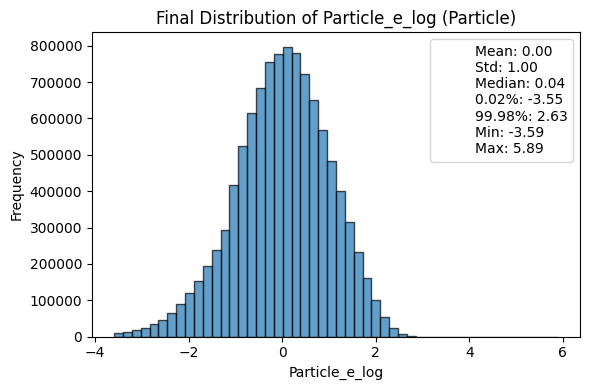

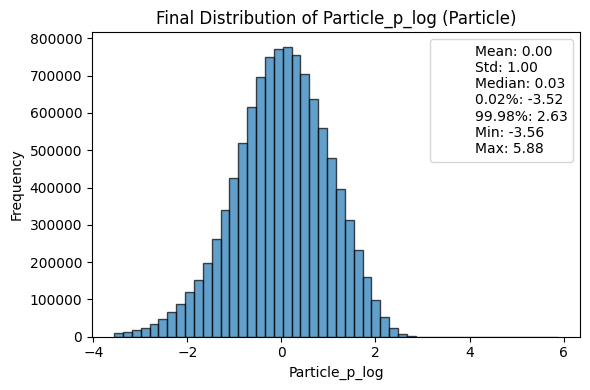

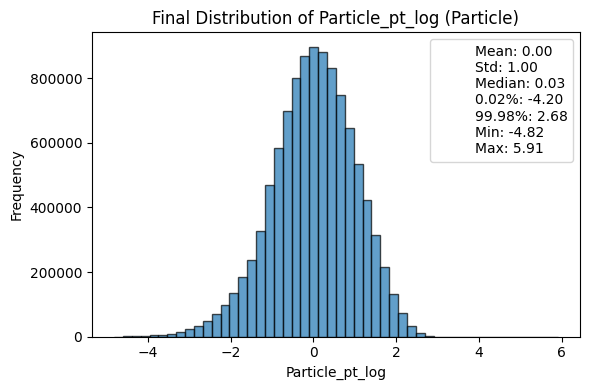

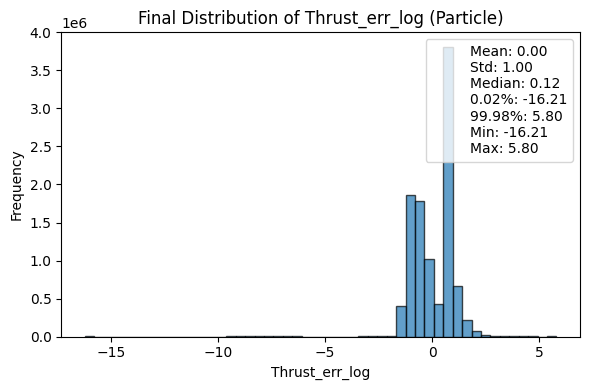

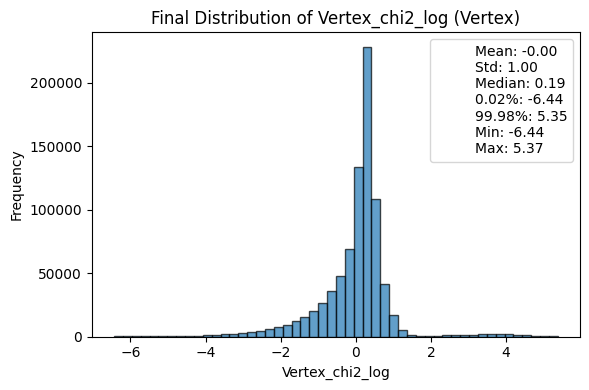

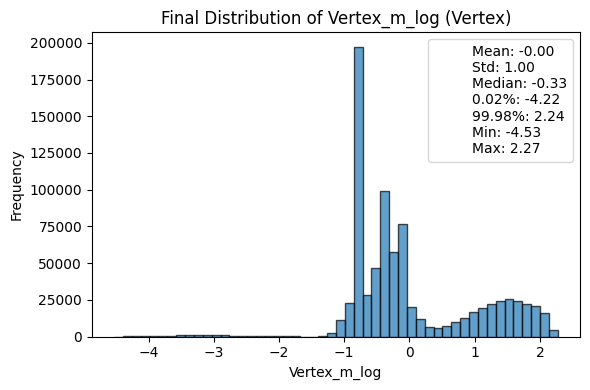

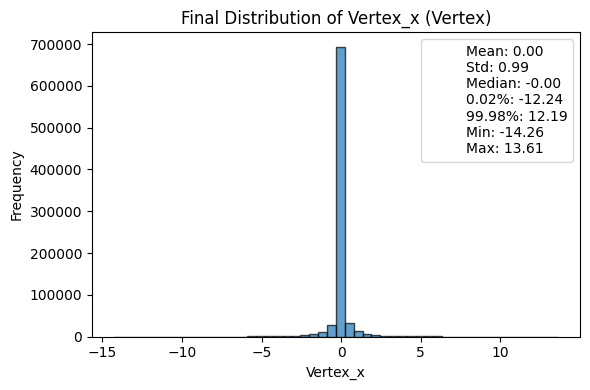

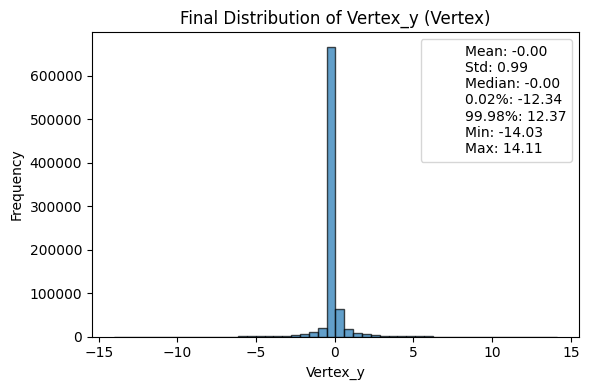

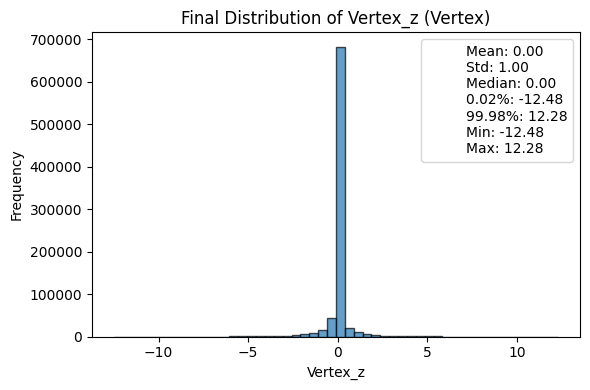

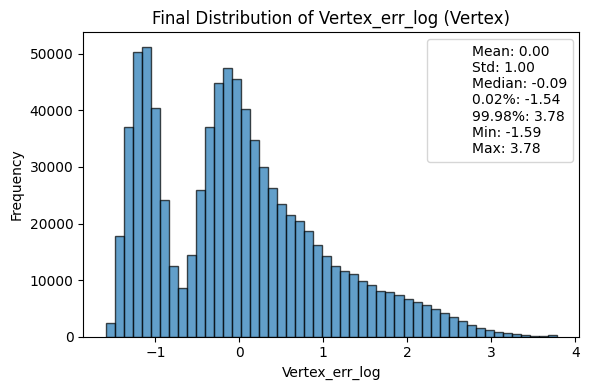

In [24]:
def plot_hist_for_vars(var_list, data_type, dfs_dict, flavor_list=['Zbb', 'Zss', 'Zcc']):
    """
    This function loops over the variables in var_list, combines data from the given flavors 
    in dfs_dict, computes statistics, plots a histogram with legend showing mean, std, median, 
    0.02%, 99.98%, min, and max, and then displays the plot.
    
    Parameters:
        var_list (list of str): List of variable names to plot.
        data_type (str): Data type, e.g., "Particle" or "Vertex".
        dfs_dict (dict): Dictionary containing DataFrames keyed by flavor.
        flavor_list (list of str): List of flavor keys to combine.
    """
    for var in var_list:
        # Combine the data from all specified flavors for the current variable
        combined_arr = np.concatenate([dfs_dict[flavor][var].values for flavor in flavor_list])
        
        # Compute statistics
        mean_val   = np.mean(combined_arr)
        std_val    = np.std(combined_arr)
        median_val = np.median(combined_arr)
        p0_02      = np.percentile(combined_arr, 0.02)
        p99_98     = np.percentile(combined_arr, 99.98)
        min_val    = np.min(combined_arr)
        max_val    = np.max(combined_arr)
        
        # Plot histogram
        plt.figure(figsize=(6, 4))
        plt.hist(combined_arr, bins=50, alpha=0.7, edgecolor='black')
        plt.xlabel(var)
        plt.ylabel("Frequency")
        plt.title(f"Final Distribution of {var} ({data_type})")
        plt.tight_layout()
        
        # Prepare legend text with computed statistics
        legend_text = (f"Mean: {mean_val:.2f}\n"
                       f"Std: {std_val:.2f}\n"
                       f"Median: {median_val:.2f}\n"
                       f"0.02%: {p0_02:.2f}\n"
                       f"99.98%: {p99_98:.2f}\n"
                       f"Min: {min_val:.2f}\n"
                       f"Max: {max_val:.2f}")
        plt.plot([], [], ' ', label=legend_text)
        plt.legend(loc='upper right')
        
        plt.show()
        plt.close()

# plot many histograms
plot_hist_for_vars(particle_standardize_vars, "Particle", dfs_particle)
plot_hist_for_vars(vertex_standardize_vars, "Vertex", dfs_vertex)

In [25]:
# This cell takes about 10 minutes to run 

MAX_PARTICLES = 35
selected_particles = {}  # Used to store processed data for each flavor

for flavor in ['Zbb', 'Zss', 'Zcc']:
    df = dfs_particle[flavor]
    # Group by 'entry', where each entry represents an event
    grouped = df.groupby(level="entry")
    processed_events = []  
    for entry, group in tqdm(grouped):
        # Separate charged and neutral particles
        charged = group[group['Particle_q'] != 0]
        neutral = group[group['Particle_q'] == 0]
        
        #  # Sort by Particle_pt_log in descending order (highest transverse momentum first)
        charged_sorted = charged.sort_values(by='Particle_pt_log', ascending=False)
        neutral_sorted = neutral.sort_values(by='Particle_pt_log', ascending=False)
        
        n_charged = charged_sorted.shape[0]
        if n_charged >= MAX_PARTICLES:
            # If there are enough charged particles, select only the top MAX_PARTICLES with highest pt
            selected = charged_sorted.head(MAX_PARTICLES)
        else:
            # If there are not enough charged particles, select all of them and fill the rest with neutral particles
            num_needed = MAX_PARTICLES - n_charged
            selected = pd.concat([charged_sorted, neutral_sorted.head(num_needed)])
        
        # If the total selected particles are still less than MAX_PARTICLES, pad with -999
        if selected.shape[0] < MAX_PARTICLES:
            missing = MAX_PARTICLES - selected.shape[0]
            pad_df = pd.DataFrame(-999, index=np.arange(missing), columns=selected.columns)
            selected = pd.concat([selected, pad_df], ignore_index=True)
        else:
            selected = selected.head(MAX_PARTICLES)
        
        # Add a column for the particle index within the event (0 to MAX_PARTICLES-1) and the event ID
        selected['subentry'] = np.arange(MAX_PARTICLES)
        selected['entry'] = entry
        
        processed_events.append(selected)
    
    # Combine all event data without ignoring index so we can set a MultiIndex later
    df_event = pd.concat(processed_events, axis=0)
    df_event.set_index(['entry', 'subentry'], inplace=True)
    selected_particles[flavor] = df_event

100%|██████████| 80000/80000 [02:49<00:00, 470.67it/s]


In [26]:
# This cell takes about 5 minutes to run 

MAX_VERTEX = 5
selected_vertices = {}  

for flavor in ['Zbb', 'Zss', 'Zcc']:
    df = dfs_vertex[flavor]
    #
    grouped = df.groupby(level="entry") # # Group by 'entry', where each entry represents an event
    processed_events = []  
    for entry, group in tqdm(grouped):
        # # Sort by Vertex_ntracks in descending order (vertices with more tracks come first)
        group_sorted = group.sort_values(by='Vertex_ntracks', ascending=False)
        # If there are enough vertices, take the top MAX_VERTEX rows; otherwise, pad with -999 rows
        if group_sorted.shape[0] >= MAX_VERTEX:
            selected = group_sorted.head(MAX_VERTEX).copy()
        else:
            selected = group_sorted.copy()
            missing = MAX_VERTEX - selected.shape[0]
            pad_df = pd.DataFrame(-999, index=np.arange(missing), columns=selected.columns)
            selected = pd.concat([selected, pad_df], ignore_index=True).copy()
            
        selected.loc[:, 'subentry'] = np.arange(MAX_VERTEX)
        selected.loc[:, 'entry'] = entry
        processed_events.append(selected)

    # Combine all event data without ignoring index so we can set a MultiIndex later
    df_event = pd.concat(processed_events, axis=0)
    df_event.set_index(['entry', 'subentry'], inplace=True)
    selected_vertices[flavor] = df_event

for flavor in ["Zbb", "Zss", "Zcc"]:
    print(f"number of primary vertices: {dfs_vertex[flavor]['Vertex_isPV'].sum()}")

100%|██████████| 80000/80000 [01:18<00:00, 1024.16it/s]


number of primary vertices: 80000
number of primary vertices: 80000
number of primary vertices: 80000


In [27]:
def df_to_np(df_particles,  # selected_particles[flavor]   shape: (nEvents*35, n_columns)
    df_vertices,   # selected_vertices[flavor]    shape: (nEvents*5, n_columns)
    entry_start,   # slicing range
    entry_stop):
    """
    Convert the particle and vertex DataFrames for a given flavor in the range entry_start~entry_stop into numpy arrays.
    Returns:
        Xp: (nEvents, 35, nParFeatures)
        Xv: (nEvents, 5,  nVerFeatures)
    """
    nEvents = entry_stop - entry_start
    
    # 1) Particle part
    #   MultiIndex: (entry, subentry=0..34)
    #   Group by entry, then sort by subentry (to keep order 0..34)
    #   Convert to shape: (nEvents, 35, nParFeatures)
    df_particles_slice = df_particles.loc[slice(entry_start, entry_stop-1) ] 
    
    
    par_cols = df_particles_slice.columns
    # group by entry
    grouped_par = df_particles_slice.groupby(level='entry', sort=False)
    # take nParFeatures
    nParFeatures = len(par_cols)
    
    Xp = np.zeros((nEvents, 35, nParFeatures), dtype=np.float32)
    
    for ientry in range(entry_start, entry_stop):
        df_event = grouped_par.get_group(ientry)
        df_event = df_event.sort_values(by='subentry')
        Xp[ientry - entry_start] = df_event[par_cols].values
    
    # 2) Vertex part
    df_vertices_slice = df_vertices.loc[
        slice(entry_start, entry_stop-1)]
    ver_cols = df_vertices_slice.columns
    nVerFeatures = len(ver_cols)
    
    Xv = np.zeros((nEvents, 5, nVerFeatures), dtype=np.float32)
    
    grouped_ver = df_vertices_slice.groupby(level='entry', sort=False)
    for ientry in range(entry_start, entry_stop):
        df_event = grouped_ver.get_group(ientry)
        df_event = df_event.sort_values(by='subentry')
        Xv[ientry - entry_start] = df_event[ver_cols].values
    
    return Xp, Xv, list(par_cols), list(ver_cols)

def write_to_hdf5_group(h5file, group_name, df_particles, df_vertices, entry_start, entry_stop, label_onehot):
    """
    Convert the data within the event range [entry_start, entry_stop) into numpy arrays
    and write it to the specified group in the HDF5 file.

    Each group will contain three datasets: 'particles', 'vertices', and 'labels'.
    If the group does not exist, it will be created; if it exists, the new data will be appended.

    Args:
        h5file: Output HDF5 file path.
        group_name: Name of the group to write data into ("train", "val", "test").
        df_particles, df_vertices: DataFrames for a given flavor.
            The MultiIndex must contain "entry" and "subentry" as levels.
        entry_start, entry_stop: Range of events to process.
        label_onehot: One-hot encoded label for the current flavor (e.g., [1, 0, 0]).
    """
    # # Convert DataFrames to numpy arrays
    Xp, Xv, par_cols, ver_cols = df_to_np(df_particles, df_vertices, entry_start, entry_stop)
    nEvents = Xp.shape[0]
    y = np.tile(label_onehot, (nEvents, 1)).astype(np.float32)
    
    with h5py.File(h5file, 'a') as f: # Open HDF5 file in append mode
        if group_name not in f:
            grp = f.create_group(group_name)
            grp.create_dataset('particles', data=Xp, maxshape=(None, Xp.shape[1], Xp.shape[2]), chunks=True)
            grp.create_dataset('vertices', data=Xv, maxshape=(None, Xv.shape[1], Xv.shape[2]), chunks=True)
            grp.create_dataset('labels', data=y, maxshape=(None, y.shape[1]), chunks=True)

            grp.attrs['particle_columns'] = json.dumps(par_cols)
            grp.attrs['vertex_columns'] = json.dumps(ver_cols)
        else:
            grp = f[group_name]
            old_size = grp['particles'].shape[0]
            new_size = old_size + nEvents
            grp['particles'].resize((new_size, Xp.shape[1], Xp.shape[2]))
            grp['vertices'].resize((new_size, Xv.shape[1], Xv.shape[2]))
            grp['labels'].resize((new_size, y.shape[1]))
            grp['particles'][old_size:new_size] = Xp
            grp['vertices'][old_size:new_size] = Xv
            grp['labels'][old_size:new_size] = y

def final_shuffle_hdf5_groups(h5file, group_names, seed=42):
    """
    Shuffle all data within each group (particles, vertices, labels) in the given HDF5 file.
    The shuffle is reproducible using the specified random seed.
    """
    np.random.seed(seed)
    with h5py.File(h5file, 'a') as f:
        for group_name in group_names:
            grp = f[group_name]
            particles = grp['particles'][:]
            vertices = grp['vertices'][:]
            labels = grp['labels'][:]
            n = particles.shape[0]
            indices = np.arange(n)
            np.random.shuffle(indices)
            grp['particles'][:] = particles[indices]
            grp['vertices'][:] = vertices[indices]
            grp['labels'][:] = labels[indices]

In [28]:
# ---------------------------
# This cell takes about 5 minutes to run
#   For each flavor: the first TRAIN_NUM events will be used for training,
#   the next VAL_NUM for validation, and the following TEST_NUM for testing.
#   Finally, data within each group will be shuffled.
# ---------------------------

TRAIN_NUM = 50000
VAL_NUM   = 15000
TEST_NUM  = 15000

flavor_map = {'Zbb': 0, 'Zss': 1, 'Zcc': 2}


out_h5_path = 'dataset/zqq_flavor.h5'
import os
if os.path.exists(out_h5_path):
    os.remove(out_h5_path)

# Write each flavor sequentially to the corresponding group
for flavor in tqdm(['Zbb', 'Zss', 'Zcc']):
    label_idx = flavor_map[flavor]
    # # Construct one-hot label (e.g., [1, 0, 0] for Zbb)
    label_onehot = np.zeros((3,), dtype=np.float32)
    label_onehot[label_idx] = 1.0
    
    write_to_hdf5_group(out_h5_path, # Write training set (first TRAIN_NUM events)
        group_name='train',
        df_particles=selected_particles[flavor],
        df_vertices=selected_vertices[flavor],
        entry_start=0,
        entry_stop=TRAIN_NUM,
        label_onehot=label_onehot)
    
    write_to_hdf5_group(out_h5_path, # Write validation set (next VAL_NUM events)
        group_name='val',
        df_particles=selected_particles[flavor],
        df_vertices=selected_vertices[flavor],
        entry_start=TRAIN_NUM,
        entry_stop=TRAIN_NUM+VAL_NUM,
        label_onehot=label_onehot)
   
    write_to_hdf5_group(out_h5_path,  # Write test set (final TEST_NUM events)
        group_name='test',
        df_particles=selected_particles[flavor],
        df_vertices=selected_vertices[flavor],
        entry_start=TRAIN_NUM+VAL_NUM,
        entry_stop=TRAIN_NUM+VAL_NUM+TEST_NUM,
        label_onehot=label_onehot)


# Finally, shuffle all data within each group (with fixed random seed)
final_shuffle_hdf5_groups(out_h5_path, group_names=['train', 'val', 'test'], seed=42)

print("Data has been written to the 'train', 'val', and 'test' groups and shuffled internally.")

100%|██████████| 3/3 [03:07<00:00, 62.36s/it]


Data has been written to the 'train', 'val', and 'test' groups and shuffled internally.


In [29]:
# Prepare modified selected_particles by dropping Particle_ID and Particle_orivtx_ind (if they exist)
modified_selected_particles = {}
for flavor in ['Zbb', 'Zss', 'Zcc']:
    modified_selected_particles[flavor] = selected_particles[flavor].drop(columns=['Particle_ID', 'Particle_orivtx_ind'], errors='ignore')

# Write modified HDF5 file (without Particle_ID and Particle_orivtx_ind)
modified_h5_path = 'dataset/zqq_flavor_v2.h5'
if os.path.exists(modified_h5_path):
    os.remove(modified_h5_path)

# Loop over each flavor and write data to modified HDF5 file
for flavor in tqdm(['Zbb', 'Zss', 'Zcc']):
    label_idx = flavor_map[flavor]
    label_onehot = np.zeros((3,), dtype=np.float32)
    label_onehot[label_idx] = 1.0
    
    write_to_hdf5_group(modified_h5_path,
                        group_name='train',
                        df_particles=modified_selected_particles[flavor],
                        df_vertices=selected_vertices[flavor],
                        entry_start=0,
                        entry_stop=TRAIN_NUM,
                        label_onehot=label_onehot)
    
    write_to_hdf5_group(modified_h5_path,
                        group_name='val',
                        df_particles=modified_selected_particles[flavor],
                        df_vertices=selected_vertices[flavor],
                        entry_start=TRAIN_NUM,
                        entry_stop=TRAIN_NUM+VAL_NUM,
                        label_onehot=label_onehot)
    
    write_to_hdf5_group(modified_h5_path,
                        group_name='test',
                        df_particles=modified_selected_particles[flavor],
                        df_vertices=selected_vertices[flavor],
                        entry_start=TRAIN_NUM+VAL_NUM,
                        entry_stop=TRAIN_NUM+VAL_NUM+TEST_NUM,
                        label_onehot=label_onehot)

final_shuffle_hdf5_groups(modified_h5_path, group_names=['train', 'val', 'test'], seed=42)
print("Modified HDF5 data (without Particle_ID and Particle_orivtx_ind) has been written and shuffled.")

100%|██████████| 3/3 [03:12<00:00, 64.24s/it]


Modified HDF5 data (without Particle_ID and Particle_orivtx_ind) has been written and shuffled.


In [30]:
def print_hdf5_structure(obj, indent=0):
    """
    Recursively print the structure and metadata (attributes) of an HDF5 file or group,
    without printing the actual dataset content.
    """
    spacing = "  " * indent
    if isinstance(obj, h5py.File) or isinstance(obj, h5py.Group):
        print(f"{spacing}Group: {obj.name}")
        # Print all attributes of the group
        if obj.attrs:
            print(f"{spacing}  Attributes:")
            for key, value in obj.attrs.items():
                print(f"{spacing}    {key}: {value}")
        # Recursively traverse all members
        for key in obj.keys():
            print_hdf5_structure(obj[key], indent+1)
    elif isinstance(obj, h5py.Dataset):
        print(f"{spacing}Dataset: {obj.name}")
        print(f"{spacing}  Shape: {obj.shape}, Dtype: {obj.dtype}")
        if obj.attrs:
            print(f"{spacing}  Attributes:")
            for key, value in obj.attrs.items():
                print(f"{spacing}    {key}: {value}")
    else:
        print(f"{spacing}{obj}")

# Open the file and print its internal structure and metadata
h5_path = "dataset/zqq_flavor.h5"
with h5py.File(h5_path, 'r') as f:
    print("HDF5 info:")
    print_hdf5_structure(f)

HDF5 info:
Group: /
  Group: /test
    Attributes:
      particle_columns: ["nParticle", "Particle_m", "Particle_q", "Particle_eta", "Particle_ID", "Particle_orivtx_ind", "Particle_e_log", "Particle_p_log", "Particle_pt_log", "Thrust_err_log", "Particle_phi_sin", "Particle_phi_cos", "Particle_angle_to_thrust_sin", "Particle_angle_to_thrust_cos"]
      vertex_columns: ["Vertex_ntracks", "Vertex_isPV", "Vertex_x", "Vertex_y", "Vertex_z", "Vertex_chi2_log", "Vertex_m_log", "Vertex_err_log"]
    Dataset: /test/labels
      Shape: (45000, 3), Dtype: float32
    Dataset: /test/particles
      Shape: (45000, 35, 14), Dtype: float32
    Dataset: /test/vertices
      Shape: (45000, 5, 8), Dtype: float32
  Group: /train
    Attributes:
      particle_columns: ["nParticle", "Particle_m", "Particle_q", "Particle_eta", "Particle_ID", "Particle_orivtx_ind", "Particle_e_log", "Particle_p_log", "Particle_pt_log", "Thrust_err_log", "Particle_phi_sin", "Particle_phi_cos", "Particle_angle_to_thrust_sin",

In [31]:
h5_path = "dataset/zqq_flavor_v2.h5"
with h5py.File(h5_path, 'r') as f:
    print("HDF5 info:")
    print_hdf5_structure(f)

HDF5 info:
Group: /
  Group: /test
    Attributes:
      particle_columns: ["nParticle", "Particle_m", "Particle_q", "Particle_eta", "Particle_e_log", "Particle_p_log", "Particle_pt_log", "Thrust_err_log", "Particle_phi_sin", "Particle_phi_cos", "Particle_angle_to_thrust_sin", "Particle_angle_to_thrust_cos"]
      vertex_columns: ["Vertex_ntracks", "Vertex_isPV", "Vertex_x", "Vertex_y", "Vertex_z", "Vertex_chi2_log", "Vertex_m_log", "Vertex_err_log"]
    Dataset: /test/labels
      Shape: (45000, 3), Dtype: float32
    Dataset: /test/particles
      Shape: (45000, 35, 12), Dtype: float32
    Dataset: /test/vertices
      Shape: (45000, 5, 8), Dtype: float32
  Group: /train
    Attributes:
      particle_columns: ["nParticle", "Particle_m", "Particle_q", "Particle_eta", "Particle_e_log", "Particle_p_log", "Particle_pt_log", "Thrust_err_log", "Particle_phi_sin", "Particle_phi_cos", "Particle_angle_to_thrust_sin", "Particle_angle_to_thrust_cos"]
      vertex_columns: ["Vertex_ntracks", "V

In [32]:
# --------------------------------------------
# 从 selected_particles / selected_vertices 重新写 3 份 ablation 数据
# --------------------------------------------
import os, numpy as np, h5py
from tqdm import tqdm   # 你原来就用过

OUT_DIR = 'dataset'     # 保存位置
ABLATION = {
    'zqq_no_ntrk.h5' : ['Vertex_ntracks'],                   # 只删 ntracks
    'zqq_no_vmass.h5': ['Vertex_m_log'],                     # 只删 m_log
    'zqq_no_both.h5' : ['Vertex_ntracks', 'Vertex_m_log'],   # 两列都删
}

# ---------- 1) 粒子表：继续沿用“已去掉 ID / orivtx”的版本 ----------
modified_selected_particles = {}
for flavor in ['Zbb', 'Zss', 'Zcc']:
    df_part = selected_particles[flavor].drop(
        columns=['Particle_ID', 'Particle_orivtx_ind'],
        errors='ignore')
    modified_selected_particles[flavor] = df_part

# ---------- 2) 依次写出每个 ablation 文件 ----------
for h5_name in ABLATION:
    h5_path = os.path.join(OUT_DIR, h5_name)

    # 若已存在旧文件，先删除
    if os.path.exists(h5_path):
        os.remove(h5_path)

    # 需要从顶点表删掉的列
    del_cols = ABLATION[h5_name]

    # --- 为进度条打印用 ---
    print(f'\n>> Building {h5_name}  (drop {del_cols})')

    # ---------- 逐个 flavour 写入 ----------
    for flavor in tqdm(['Zbb', 'Zss', 'Zcc']):
        # 2-a) 处理顶点 DataFrame：删除对应列
        df_vert_cut = selected_vertices[flavor].drop(
            columns=del_cols,
            errors='ignore')

        # 2-b) 取粒子 DataFrame（已无 ID / orivtx）
        df_part_cut = modified_selected_particles[flavor]

        # 2-c) 构造 one-hot 标签
        label_idx       = flavor_map[flavor]        # 0 / 1 / 2
        label_onehot    = np.zeros((3,), dtype=np.float32)
        label_onehot[label_idx] = 1.0

        # 2-d) 写三段（train / val / test）
        write_to_hdf5_group(
            h5_path, 'train',
            df_particles=df_part_cut,
            df_vertices=df_vert_cut,
            entry_start=0,
            entry_stop=TRAIN_NUM,
            label_onehot=label_onehot)

        write_to_hdf5_group(
            h5_path, 'val',
            df_particles=df_part_cut,
            df_vertices=df_vert_cut,
            entry_start=TRAIN_NUM,
            entry_stop=TRAIN_NUM + VAL_NUM,
            label_onehot=label_onehot)

        write_to_hdf5_group(
            h5_path, 'test',
            df_particles=df_part_cut,
            df_vertices=df_vert_cut,
            entry_start=TRAIN_NUM + VAL_NUM,
            entry_stop=TRAIN_NUM + VAL_NUM + TEST_NUM,
            label_onehot=label_onehot)

    # ---------- 3) 每个文件内部再随机打乱 ----------
    final_shuffle_hdf5_groups(
        h5_path,
        group_names=['train', 'val', 'test'],
        seed=42)

    print(f'   {h5_name} written & shuffled.')

print('\n=== 全部 ablation HDF5 生成完毕 ===')



>> Building zqq_no_ntrk.h5  (drop ['Vertex_ntracks'])


100%|██████████| 3/3 [03:19<00:00, 66.43s/it]


   zqq_no_ntrk.h5 written & shuffled.

>> Building zqq_no_vmass.h5  (drop ['Vertex_m_log'])


100%|██████████| 3/3 [03:34<00:00, 71.56s/it]


   zqq_no_vmass.h5 written & shuffled.

>> Building zqq_no_both.h5  (drop ['Vertex_ntracks', 'Vertex_m_log'])


100%|██████████| 3/3 [03:47<00:00, 75.86s/it]


   zqq_no_both.h5 written & shuffled.

=== 全部 ablation HDF5 生成完毕 ===


In [34]:
h5_path = "dataset/zqq_no_ntrk.h5"
with h5py.File(h5_path, 'r') as f:
    print("HDF5 info:")
    print_hdf5_structure(f)

HDF5 info:
Group: /
  Group: /test
    Attributes:
      particle_columns: ["nParticle", "Particle_m", "Particle_q", "Particle_eta", "Particle_e_log", "Particle_p_log", "Particle_pt_log", "Thrust_err_log", "Particle_phi_sin", "Particle_phi_cos", "Particle_angle_to_thrust_sin", "Particle_angle_to_thrust_cos"]
      vertex_columns: ["Vertex_isPV", "Vertex_x", "Vertex_y", "Vertex_z", "Vertex_chi2_log", "Vertex_m_log", "Vertex_err_log"]
    Dataset: /test/labels
      Shape: (45000, 3), Dtype: float32
    Dataset: /test/particles
      Shape: (45000, 35, 12), Dtype: float32
    Dataset: /test/vertices
      Shape: (45000, 5, 7), Dtype: float32
  Group: /train
    Attributes:
      particle_columns: ["nParticle", "Particle_m", "Particle_q", "Particle_eta", "Particle_e_log", "Particle_p_log", "Particle_pt_log", "Thrust_err_log", "Particle_phi_sin", "Particle_phi_cos", "Particle_angle_to_thrust_sin", "Particle_angle_to_thrust_cos"]
      vertex_columns: ["Vertex_isPV", "Vertex_x", "Vertex_y",

In [35]:
h5_path = "dataset/zqq_no_vmass.h5"
with h5py.File(h5_path, 'r') as f:
    print("HDF5 info:")
    print_hdf5_structure(f)

HDF5 info:
Group: /
  Group: /test
    Attributes:
      particle_columns: ["nParticle", "Particle_m", "Particle_q", "Particle_eta", "Particle_e_log", "Particle_p_log", "Particle_pt_log", "Thrust_err_log", "Particle_phi_sin", "Particle_phi_cos", "Particle_angle_to_thrust_sin", "Particle_angle_to_thrust_cos"]
      vertex_columns: ["Vertex_ntracks", "Vertex_isPV", "Vertex_x", "Vertex_y", "Vertex_z", "Vertex_chi2_log", "Vertex_err_log"]
    Dataset: /test/labels
      Shape: (45000, 3), Dtype: float32
    Dataset: /test/particles
      Shape: (45000, 35, 12), Dtype: float32
    Dataset: /test/vertices
      Shape: (45000, 5, 7), Dtype: float32
  Group: /train
    Attributes:
      particle_columns: ["nParticle", "Particle_m", "Particle_q", "Particle_eta", "Particle_e_log", "Particle_p_log", "Particle_pt_log", "Thrust_err_log", "Particle_phi_sin", "Particle_phi_cos", "Particle_angle_to_thrust_sin", "Particle_angle_to_thrust_cos"]
      vertex_columns: ["Vertex_ntracks", "Vertex_isPV", "Ve

In [36]:
h5_path = "dataset/zqq_no_both.h5"
with h5py.File(h5_path, 'r') as f:
    print("HDF5 info:")
    print_hdf5_structure(f)

HDF5 info:
Group: /
  Group: /test
    Attributes:
      particle_columns: ["nParticle", "Particle_m", "Particle_q", "Particle_eta", "Particle_e_log", "Particle_p_log", "Particle_pt_log", "Thrust_err_log", "Particle_phi_sin", "Particle_phi_cos", "Particle_angle_to_thrust_sin", "Particle_angle_to_thrust_cos"]
      vertex_columns: ["Vertex_isPV", "Vertex_x", "Vertex_y", "Vertex_z", "Vertex_chi2_log", "Vertex_err_log"]
    Dataset: /test/labels
      Shape: (45000, 3), Dtype: float32
    Dataset: /test/particles
      Shape: (45000, 35, 12), Dtype: float32
    Dataset: /test/vertices
      Shape: (45000, 5, 6), Dtype: float32
  Group: /train
    Attributes:
      particle_columns: ["nParticle", "Particle_m", "Particle_q", "Particle_eta", "Particle_e_log", "Particle_p_log", "Particle_pt_log", "Thrust_err_log", "Particle_phi_sin", "Particle_phi_cos", "Particle_angle_to_thrust_sin", "Particle_angle_to_thrust_cos"]
      vertex_columns: ["Vertex_isPV", "Vertex_x", "Vertex_y", "Vertex_z", "Ve

In [ ]:
# corr_all_features.py
import os, json, h5py, numpy as np, pandas as pd

H5  = 'dataset/zqq_flavor.h5'
OUT = 'results/feature_corr'
os.makedirs(OUT, exist_ok=True)

def jload(attr):
    return json.loads(attr.decode() if isinstance(attr, bytes) else attr)

dfs = []

with h5py.File(H5) as f:
    for split in ['train', 'val', 'test']:
        # ---------- read array ----------
        P = f[f'{split}/particles'][:]     # (N, 35, nPar)
        V = f[f'{split}/vertices'][:]      # (N, 5,  nVer)

        par_names = jload(f[split].attrs['particle_columns'])
        ver_names = jload(f[split].attrs['vertex_columns'])

        # ---------- particle DataFrame ----------
        N, NP, _ = P.shape
        df_par = (pd.DataFrame(P.reshape(-1, P.shape[-1]), columns=par_names)
                    .assign(evt=np.repeat(np.arange(N), NP)))

        # ---------- vertex DataFrame ----------
        NV = V.shape[1]
        df_ver = (pd.DataFrame(V.reshape(-1, V.shape[-1]), columns=ver_names)
                    .assign(evt=np.repeat(np.arange(N), NV)))

        # ---------- get rid of undesired columns ----------
        drop_ver = ['Vertex_isPV', 'Vertex_x', 'Vertex_y']
        drop_par = ['Particle_ID']
        df_par  = df_par.drop(columns=drop_par,   errors='ignore')
        df_ver  = df_ver.drop(columns=drop_ver,   errors='ignore')

        # ---------- replace -999 to NaN ----------
        ver_mean = (df_ver.replace(-999, np.nan)
                          .groupby('evt')
                          .mean()
                          .reset_index())

        # ---------- merge ----------
        df = df_par.merge(ver_mean, on='evt').drop(columns='evt')
        df = df.replace(-999, np.nan)

        dfs.append(df)

# ---------- concat all split ----------
data = pd.concat(dfs, ignore_index=True)

# ---------- correlation matrices ----------
pear  = data.corr('pearson')
spear = data.corr('spearman')

pear.to_csv(f'{OUT}/pearson_all.csv')
spear.to_csv(f'{OUT}/spearman_all.csv')

print('\n=== Pearson (first 10×10 block) ===')
print(pear.iloc[:10, :10].round(3))
print(f'\nMatrices saved to {OUT}/')



=== Pearson (first 10×10 block) ===
                     nParticle  Particle_m  Particle_q  Particle_eta  \
nParticle                1.000       0.072       0.000         0.000   
Particle_m               0.072       1.000       0.000        -0.000   
Particle_q               0.000       0.000       1.000        -0.001   
Particle_eta             0.000      -0.000      -0.001         1.000   
Particle_orivtx_ind      0.075      -0.022       0.000        -0.002   
Particle_e_log           0.036       0.344       0.000        -0.000   
Particle_p_log           0.031       0.314       0.000        -0.000   
Particle_pt_log          0.053       0.302       0.000         0.000   
Thrust_err_log           0.006       0.000       0.000         0.000   
Particle_phi_sin        -0.000      -0.000       0.000         0.001   

                     Particle_orivtx_ind  Particle_e_log  Particle_p_log  \
nParticle                          0.075           0.036           0.031   
Particle_m        

In [25]:
pear

,nParticle,Particle_m,Particle_q,Particle_eta,Particle_orivtx_ind,Particle_e_log,Particle_p_log,Particle_pt_log,Thrust_err_log,Particle_phi_sin,Particle_phi_cos,Particle_angle_to_thrust_sin,Particle_angle_to_thrust_cos,Vertex_ntracks,Vertex_z,Vertex_chi2_log,Vertex_m_log,Vertex_err_log
nParticle,1.000,0.072,0.000,0.000,0.075,0.036,0.031,0.053,0.006,-0.000,-0.000,0.154,-0.006,0.105,-0.001,-0.078,-0.193,0.049
Particle_m,0.072,1.000,0.000,-0.000,-0.022,0.344,0.314,0.302,0.000,-0.000,0.000,-0.011,-0.016,0.031,-0.000,-0.003,0.004,0.009
Particle_q,0.000,0.000,1.000,-0.001,0.000,0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000
Particle_eta,0.000,-0.000,-0.001,1.000,-0.002,-0.000,-0.000,0.000,0.000,0.001,-0.000,0.001,0.000,0.000,0.009,0.000,-0.000,-0.001
Particle_orivtx_ind,0.075,-0.022,0.000,-0.002,1.000,0.187,0.191,0.184,-0.006,0.001,-0.001,-0.264,0.020,-0.302,0.000,-0.052,-0.289,0.143
Particle_e_log,0.036,0.344,0.000,-0.000,0.187,1.000,0.998,0.947,-0.004,-0.000,0.000,-0.541,0.017,-0.006,0.000,-0.003,-0.019,0.010
Particle_p_log,0.031,0.314,0.000,-0.000,0.191,0.998,1.000,0.948,-0.004,-0.000,0.000,-0.552,0.017,-0.007,0.000,-0.002,-0.019,0.009
Particle_pt_log,0.053,0.302,0.000,0.000,0.184,0.947,0.948,1.000,-0.021,-0.000,0.000,-0.500,0.016,-0.003,0.001,0.002,-0.025,-0.020
Thrust_err_log,0.006,0.000,0.000,0.000,-0.006,-0.004,-0.004,-0.021,1.000,0.000,0.001,0.004,-0.001,0.006,0.002,-0.002,0.004,0.009
Particle_phi_sin,-0.000,-0.000,0.000,0.001,0.001,-0.000,-0.000,-0.000,0.000,1.000,-0.001,0.001,0.001,0.000,0.000,0.001,0.001,-0.000


In [26]:
spear

,nParticle,Particle_m,Particle_q,Particle_eta,Particle_orivtx_ind,Particle_e_log,Particle_p_log,Particle_pt_log,Thrust_err_log,Particle_phi_sin,Particle_phi_cos,Particle_angle_to_thrust_sin,Particle_angle_to_thrust_cos,Vertex_ntracks,Vertex_z,Vertex_chi2_log,Vertex_m_log,Vertex_err_log
nParticle,1.000,0.147,0.000,0.000,0.040,0.035,0.032,0.054,0.029,-0.000,-0.000,0.164,0.027,0.153,-0.002,-0.101,-0.184,0.030
Particle_m,0.147,1.000,0.000,-0.000,-0.046,0.322,0.297,0.287,0.006,-0.000,0.000,0.024,-0.004,0.071,-0.001,-0.017,-0.009,0.014
Particle_q,0.000,0.000,1.000,-0.001,0.000,0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000
Particle_eta,0.000,-0.000,-0.001,1.000,-0.001,-0.000,-0.000,0.000,-0.000,0.001,-0.000,0.000,-0.001,-0.000,0.027,-0.000,-0.000,-0.001
Particle_orivtx_ind,0.040,-0.046,0.000,-0.001,1.000,0.240,0.244,0.231,-0.009,0.000,-0.000,-0.328,-0.010,-0.407,0.000,-0.074,-0.335,0.133
Particle_e_log,0.035,0.322,0.000,-0.000,0.240,1.000,0.998,0.941,-0.004,-0.000,0.000,-0.581,-0.006,-0.013,0.000,-0.005,-0.016,0.008
Particle_p_log,0.032,0.297,0.000,-0.000,0.244,0.998,1.000,0.943,-0.004,-0.000,0.000,-0.589,-0.007,-0.014,0.000,-0.004,-0.016,0.007
Particle_pt_log,0.054,0.287,0.000,0.000,0.231,0.941,0.943,1.000,-0.027,-0.000,0.000,-0.537,-0.004,-0.009,0.001,-0.003,-0.023,-0.029
Thrust_err_log,0.029,0.006,0.000,-0.000,-0.009,-0.004,-0.004,-0.027,1.000,-0.000,0.001,0.025,0.003,0.019,-0.001,0.002,0.007,0.018
Particle_phi_sin,-0.000,-0.000,0.000,0.001,0.000,-0.000,-0.000,-0.000,-0.000,1.000,-0.001,0.001,0.001,-0.000,0.000,0.001,0.000,0.000
